v1 (last update April 18th 2025)

# ✍️ Problem 3: Train a MLP using PyTorch

Welcome to Problem 3 of your assignment 2, where we will delve into building and training Multilayer Perceptron (MLP) models using PyTorch on the MNIST dataset. The MNIST database is a widely used benchmark dataset in the field of machine learning, consisting of handwritten digit images.

[Official PyTorch Official Tutorial](https://pytorch.org/tutorials/)

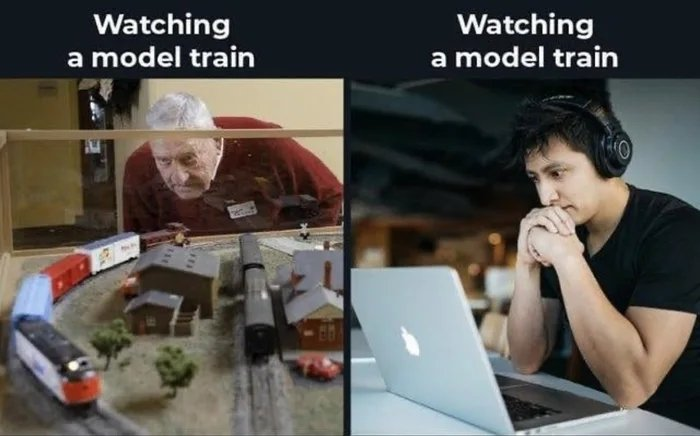




## Set-up and mount your drive

In [1]:
# Upload the data to your google drive from Canvas then mount to the folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# TODO: Change the following lines accoardingly to the path you placed your hw2 data
folder_path = "drive/MyDrive/EE443_HW2"
%ls -l drive/MyDrive/EE443_HW2

Mounted at /content/drive
total 124946
-rw------- 1 root root  18303650 Apr 14 17:14 mnist_test.csv
-rw------- 1 root root 109640201 Apr 14 17:14 mnist_train.csv


In [ ]:
%ls -l drive/MyDrive/EE443/2025_spring/release/hw2/data/data/p3

total 124946
-rw------- 1 root root  18303650 Apr 13  2023 mnist_test.csv
-rw------- 1 root root 109640201 Apr 13  2023 mnist_train.csv


In [ ]:
%cd /content/drive

/content/drive


In [ ]:
!unzip data.zip -d data

Archive:  data.zip
replace data/__MACOSX/._data? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Import packages

We need imports necessary libraries for various tasks involved in building and training neural networks using PyTorch. One nice feature of Google Colab is that it comes pre-installed with most commonly used Python packages, which saves time and effort for users as they don't need to install packages manually.

In [2]:
# Numerical Operations
import math
import numpy as np

# Reading/Writing Data
import pandas as pd
import os
import csv

# For Progress Bar
from tqdm import tqdm

# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchsummary import summary

Check the torch version that you are using:

In [3]:
torch.__version__

'2.10.0+cu128'

Check whether PyTorch is using CUDA (GPU), should return `True`, if retrun `False`, go to "Change Runtime Type" in the setting in the upper right tab:

In [4]:
assert torch.cuda.is_available() == True

Check which GPU google colab assigned your runtime to run on:

In [5]:
!nvidia-smi

Tue Apr 28 00:04:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Environment Configurations

`environ_config` contains parameters such as seed and device settings that are used across experiment.

In [6]:
environ_config = {
    'folder_path': folder_path,
    'seed': 2484345508,      # Any number, don't ask why TA chose (248)434-5508
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'  # Availability of CUDA-enabled GPU devices
}

dataset_config = {
    'batch_size': 512,
    'valid_ratio': 0.2,
}

def same_seed(seed):
    '''Fixes random number generator seeds for reproducibility.'''
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

same_seed(environ_config['seed'])

In [7]:
# Print the current random seeds for reproducibility
print("NumPy Seed:", np.random.get_state()[1][0])
print("PyTorch CPU Seed:", torch.initial_seed())

if torch.cuda.is_available():
    print("PyTorch CUDA Seed:", torch.cuda.initial_seed())
else:
    print("CUDA not available on this device.")

NumPy Seed: 2484345508
PyTorch CPU Seed: 2484345508
PyTorch CUDA Seed: 2484345508


## Dataset

Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity. PyTorch provides two data primitives: torch.utils.data.DataLoader and torch.utils.data.Dataset that allow you to use pre-loaded datasets as well as your own data. Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets (such as FashionMNIST) that subclass torch.utils.data.Dataset and implement functions specific to the particular data.



---



A custom Dataset class must implement three functions: `__init__`, `__len__`, and `__getitem__`.

### `__init__`

The `__init__` function is run once when instantiating the Dataset object.

### `__len__`

The `__len__` function returns the number of samples in our dataset.

### `__getitem__`

The `__getitem__ `function loads and returns a sample from the dataset at the given index idx.

Since the dataset we are working with is the MNIST, which already help you organize most of the data, what you will need to do is simply split the columns in the dataset into the input data and labels.

(Optional) For a more advanced version of custom dataset (a image dataset) implementation please read: [PyTorch Tutorials: Datasets & DataLoaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)

In [8]:
class MNISTDataset(Dataset):
    def __init__(self, raw_data):
        # Split the original mnist data into input data and labels
        input_data = raw_data[:, 1:]
        labels = raw_data[:, 0]

        self.x = torch.FloatTensor(input_data)
        self.y = torch.LongTensor(labels)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


def train_valid_split(data_set, valid_ratio, seed):
    '''Split provided training data into training set and validation set'''
    valid_set_size = int(valid_ratio * len(data_set))
    train_set_size = len(data_set) - valid_set_size
    train_set, valid_set = random_split(data_set, [train_set_size, valid_set_size], generator=torch.Generator().manual_seed(seed))
    return np.array(train_set), np.array(valid_set)

The Dataset retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval. DataLoader is an iterable that abstracts this complexity for us in an easy API.

In [9]:
def prepare_data_loader(environ_config, dataset_config):
    train_data = pd.read_csv(environ_config['folder_path'] + '/mnist_train.csv').values
    test_data = pd.read_csv(environ_config['folder_path'] + '/mnist_test.csv').values

    train_data, valid_data = train_valid_split(train_data, dataset_config['valid_ratio'], environ_config['seed'])

    # Print out the data size.
    print(f"""train_data size: {train_data.shape}\n valid_data size: {valid_data.shape}\n test_data size: {test_data.shape}""")

    train_dataset, valid_dataset, test_dataset = MNISTDataset(train_data), \
                                            MNISTDataset(valid_data), \
                                            MNISTDataset(test_data)

    # Pytorch data loader loads pytorch dataset into batches.
    train_loader = DataLoader(train_dataset, batch_size=dataset_config['batch_size'], shuffle=True, pin_memory=True)
    valid_loader = DataLoader(valid_dataset, batch_size=dataset_config['batch_size'], shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=dataset_config['batch_size'], shuffle=False, pin_memory=True)

    return train_loader, valid_loader, test_loader

In [10]:
train_loader, valid_loader, test_loader = prepare_data_loader(environ_config, dataset_config)

train_data size: (48000, 785)
 valid_data size: (12000, 785)
 test_data size: (10000, 785)


In [11]:
# Access the dataset object wrapped inside the DataLoader
train_dataset = train_loader.dataset

# Print the type of the dataset (e.g., TensorDataset, custom Dataset)
print("Dataset type:", type(train_dataset))

# Print the total number of samples in the dataset
print("Number of samples in dataset:", len(train_dataset))

# Print the type of a single sample in the dataset
print("Type of one sample (train_dataset[0]):", type(train_dataset[0]))

# Each sample is typically a tuple: (input, label)
print("Length of one sample tuple:", len(train_dataset[0]))

# Print the type and shape of the input (image, features, etc.)
print("Type of input (train_dataset[0][0]):", type(train_dataset[0][0]))
print("Shape of input:", train_dataset[0][0].shape)

# Print the type and shape/value of the label
print("Type of label (train_dataset[0][1]):", type(train_dataset[0][1]))
print("Label value / shape:", train_dataset[0][1].shape if hasattr(train_dataset[0][1], 'shape') else train_dataset[0][1])

Dataset type: <class '__main__.MNISTDataset'>
Number of samples in dataset: 48000
Type of one sample (train_dataset[0]): <class 'tuple'>
Length of one sample tuple: 2
Type of input (train_dataset[0][0]): <class 'torch.Tensor'>
Shape of input: torch.Size([784])
Type of label (train_dataset[0][1]): <class 'torch.Tensor'>
Label value / shape: torch.Size([])


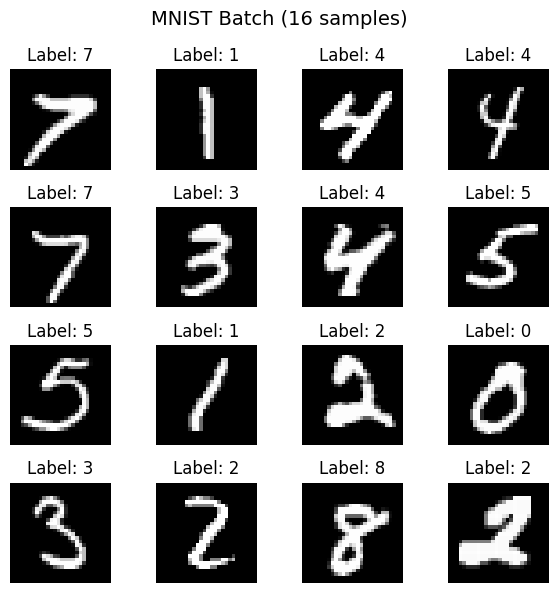

In [12]:
import matplotlib.pyplot as plt

# Get one batch from the DataLoader
images, labels = next(iter(train_loader))

# Reshape images from (batch_size, 784) to (batch_size, 28, 28)
images = images.view(-1, 28, 28)

# Plot the first 16 images in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle("MNIST Batch (16 samples)", fontsize=14)

for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(images[i].numpy(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Neural Network Model
Create a simple single-layer MLP as a baseline. You will eventually try out different model architectures by modifying the class below.

In [13]:
class My_1st_MLP_Model(nn.Module):
    def __init__(self, input_dim):
        super(My_1st_MLP_Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 20),  # First hidden layer with 20 neurons
            nn.ReLU(),                 # Activation function
            nn.Linear(20, 10),         # Output layer for 10-class classification (e.g., MNIST)
        )

    def forward(self, x):
        return self.layers(x)

Understanding the layers and their dimension in your MLP model

In [14]:
from torchsummary import summary

# Instantiate the model and move it to the desired device
model = My_1st_MLP_Model(input_dim=784).to(environ_config['device'])

# Print model architecture
print("Model Summary (PyTorch)")
print(model)
print()

# Print detailed summary using torchsummary
print("Model Summary (torchsummary)")
dummy_input_dimension = (784,)  # input size per sample (not including batch size)
summary(model, input_size=dummy_input_dimension, batch_size=10000, device=str(environ_config['device']))

Model Summary (PyTorch)
My_1st_MLP_Model(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=10, bias=True)
  )
)

Model Summary (torchsummary)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [10000, 20]          15,700
              ReLU-2                [10000, 20]               0
            Linear-3                [10000, 10]             210
Total params: 15,910
Trainable params: 15,910
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 29.91
Forward/backward pass size (MB): 3.81
Params size (MB): 0.06
Estimated Total Size (MB): 33.78
----------------------------------------------------------------


## Training Loop

In [17]:
def trainer(train_loader, valid_loader, model, config, device):
    # Define your loss algorithm
    criterion = nn.CrossEntropyLoss(reduction='mean')

    # Define your optimization algorithm
    optimizer = torch.optim.SGD(model.parameters(), lr=config['learning_rate'], momentum=0.7)

    if not os.path.isdir('./models'):
        os.mkdir('./models') # Create directory of saving models.

    n_epochs, best_loss, step, early_stop_count = config['n_epochs'], math.inf, 0, 0

    train_loss_epoch_history, train_loss_batch_history = [], []
    valid_loss_epoch_history, valid_acc_history = [], []

    for epoch in range(n_epochs):
        model.train() # Set your model to train mode.

        # tqdm is a package to visualize your training progress.
        train_pbar = tqdm(train_loader, position=0, leave=True)
        train_loss_batch_history = []

        for x, y in train_pbar:
            # Training (Batch)
            # TODO: We need to use the (data, label) pair to calculate the loss in order to update the weights of the model
            # Step 1: Set your gradient to zero (recall that the optimizer controls/saves the gradient)
            # Step 2: Place your (data, label) pair (e.g., x and y) to the GPU using .to(device)
            # Step 3: Obtain the prediction by feeding data x into the model
            # Step 4: Calculate Loss using loss = criterion(outputs, labels) and the gradient of it using loss.backward()
            # Step 5: Update the weights using optimzer.step()
            # Step 6: Magic!
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()


            # Display current epoch number and loss on tqdm progress bar.
            train_pbar.set_description(f'Epoch [{epoch+1}/{n_epochs}]')
            train_pbar.set_postfix({'loss': loss.detach().item()})

            train_loss_batch_history.append(loss.detach().item())

        mean_train_loss = sum(train_loss_batch_history)/len(train_loss_batch_history)
        train_loss_epoch_history.append(mean_train_loss)

        model.eval() # Set your model to evaluation mode.
        valid_loss_batch_history = []
        val_accuracy = []
        for x, y in valid_loader:
            inputs, labels = x.to(device), y.to(device)
            with torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, predicted = torch.max(outputs.data, 1)
                val_accuracy.append((predicted == labels).sum().item() / predicted.size(0))

            valid_loss_batch_history.append(loss.item())

        mean_valid_loss = sum(valid_loss_batch_history)/len(valid_loss_batch_history)
        overall_val_accuracy = np.mean(val_accuracy)
        valid_loss_epoch_history.append(mean_valid_loss)
        valid_acc_history.append(overall_val_accuracy)

        print(f'Epoch [{epoch+1}/{n_epochs}]: Train loss: {mean_train_loss:.4f}, Valid loss: {mean_valid_loss:.4f} Valid acc: {overall_val_accuracy:.4f}')

        # Save your best model
        # TODO: We want to save the model whenever the validation_loss < best_loss
        # (hint 1): use torch.save(model.state_dict(), config['save_path']) to save your model
        # (hint 2): remember to reset the early_stop_count when a better model is being saved
        # (hint 3): remember to update the early_stop_count when the current epoch perform worse
        if mean_valid_loss < best_loss:
            best_loss = mean_valid_loss
            torch.save(model.state_dict(), config['save_path'])
            early_stop_count = 0
        else:
            early_stop_count += 1


        if early_stop_count >= config['early_stop']:
            print('\nModel is not improving, so we halt the training session.')
            return train_loss_epoch_history, valid_loss_epoch_history, valid_acc_history

    return train_loss_epoch_history, valid_loss_epoch_history, valid_acc_history

## Start training!

In [18]:
model = My_1st_MLP_Model(input_dim=784).to(environ_config['device']) # put your model and data on the same computation device.

model_config = {
    'n_epochs': 200,     # Number of epochs.
    'learning_rate': 0.01,
    'early_stop': 10,    # If model has not improved for this many consecutive epochs, stop training.
    'save_path': './models/model.ckpt'  # Your model will be saved here.
}

train_loss_epoch_history, valid_loss_history, valid_acc_history = trainer(train_loader, valid_loader, model, model_config, environ_config['device'])

Epoch [1/200]: 100%|██████████| 94/94 [00:01<00:00, 84.37it/s, loss=2.07] 


Epoch [1/200]: Train loss: 2.4245, Valid loss: 2.0563 Valid acc: 0.2124


Epoch [2/200]: 100%|██████████| 94/94 [00:00<00:00, 124.08it/s, loss=2]


Epoch [2/200]: Train loss: 2.0124, Valid loss: 1.9551 Valid acc: 0.2824


Epoch [3/200]: 100%|██████████| 94/94 [00:00<00:00, 114.33it/s, loss=1.92]


...

Epoch [17/200]: Train loss: 1.9441, Valid loss: 1.9450 Valid acc: 0.2545


Epoch [18/200]: 100%|██████████| 94/94 [00:01<00:00, 91.70it/s, loss=1.97]


Epoch [18/200]: Train loss: 1.8950, Valid loss: 1.9034 Valid acc: 0.2808


Epoch [19/200]: 100%|██████████| 94/94 [00:00<00:00, 112.80it/s, loss=1.76]


Epoch [19/200]: Train loss: 1.8702, Valid loss: 1.8789 Valid acc: 0.2777

Model is not improving, so we halt the training session.


Let's do the testing using the `predict()` function:

In [19]:
def predict(test_loader, model, device):
    model.eval() # Set your model to evaluation mode.
    test_accuracy = []
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            pred = model(x)
            _, predicted = torch.max(pred.data, 1)
            test_accuracy.append((predicted == y).sum().item() / predicted.size(0))
    return np.mean(test_accuracy)

model.load_state_dict(torch.load(model_config['save_path']))
test_accuracy = predict(test_loader, model, environ_config['device'])

print(f"The testing accurcay of 1st model: {test_accuracy*100}%")

The testing accurcay of 1st model: 29.552504595588236%


The result probably don't look to good, let's try modifying our MLP model to make the test accuracy to go over 90%.

In [20]:
class My_2nd_MLP_Model(nn.Module):
    def __init__(self, input_dim):
        super(My_2nd_MLP_Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = x / 255.0
        x = self.layers(x)
        return x

In [21]:
model_2 = My_2nd_MLP_Model(input_dim=784).to(environ_config['device']) # put your model and data on the same computation device.

model_config_2 = {
    'n_epochs': 200,     # Number of epochs.
    'learning_rate': 0.01,
    'early_stop': 10,    # If model has not improved for this many consecutive epochs, stop training.
    'save_path': './models/model2.ckpt'  # Your model will be saved here.
}

train_loss_epoch_history_2, valid_loss_history_2, valid_acc_history_2 = trainer(train_loader, valid_loader, model_2, model_config_2, environ_config['device'])

Epoch [1/200]: 100%|██████████| 94/94 [00:00<00:00, 127.67it/s, loss=2.15]


Epoch [1/200]: Train loss: 2.2494, Valid loss: 2.1516 Valid acc: 0.5558


Epoch [2/200]: 100%|██████████| 94/94 [00:01<00:00, 84.72it/s, loss=1.48]


Epoch [2/200]: Train loss: 1.8785, Valid loss: 1.4670 Valid acc: 0.6836


Epoch [3/200]: 100%|██████████| 94/94 [00:00<00:00, 113.10it/s, loss=0.848]


...

Epoch [195/200]: Train loss: 0.0251, Valid loss: 0.0808 Valid acc: 0.9773


Epoch [196/200]: 100%|██████████| 94/94 [00:00<00:00, 105.73it/s, loss=0.0157]


Epoch [196/200]: Train loss: 0.0248, Valid loss: 0.0817 Valid acc: 0.9770


Epoch [197/200]: 100%|██████████| 94/94 [00:01<00:00, 79.65it/s, loss=0.024]


Epoch [197/200]: Train loss: 0.0245, Valid loss: 0.0813 Valid acc: 0.9772

Model is not improving, so we halt the training session.


In [22]:
model_2.load_state_dict(torch.load(model_config_2['save_path']))
test_accuracy = predict(test_loader, model_2, environ_config['device'])

print(f"The testing accurcay of 2nd model: {test_accuracy*100}%")

The testing accurcay of 2nd model: 97.7188648897059%


## Plotting the training curve


Plotting the training curve is important because it provides valuable insights into the performance and behavior of the model during the training process. Here are several reasons why plotting the training curve is crucial:

1. Performance Monitoring: The training curve allows us to monitor the performance metrics (e.g., loss, accuracy) of the model over epochs. This helps us understand how well the model is learning from the training data and whether it is converging towards the desired performance.

2. Detection of Overfitting and Underfitting: By analyzing the training curve, we can identify signs of overfitting or underfitting. Overfitting occurs when the model performs well on the training data but poorly on unseen data, while underfitting indicates that the model is too simple to capture the underlying patterns in the data. Plotting the training curve helps us visualize these phenomena and take appropriate measures to address them.


In [23]:
import matplotlib.pyplot as plt

def plot(train_loss_epoch_history, valid_loss_history):
    """
    Plots the training and validation loss histories over epochs.

    Args:
    train_loss_history (list): List containing training loss values for each epoch.
    valid_loss_history (list): List containing validation loss values for each epoch.
    """
    epochs = range(1, len(train_loss_epoch_history) + 1)  # Number of epochs

    # Plotting training and validation loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_loss_epoch_history, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, valid_loss_history, label='Validation Loss', marker='o', color='orange')

    # Adding labels and title
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')

    # Adding legend
    plt.legend()

    # Display plot
    plt.grid(True)
    plt.show()

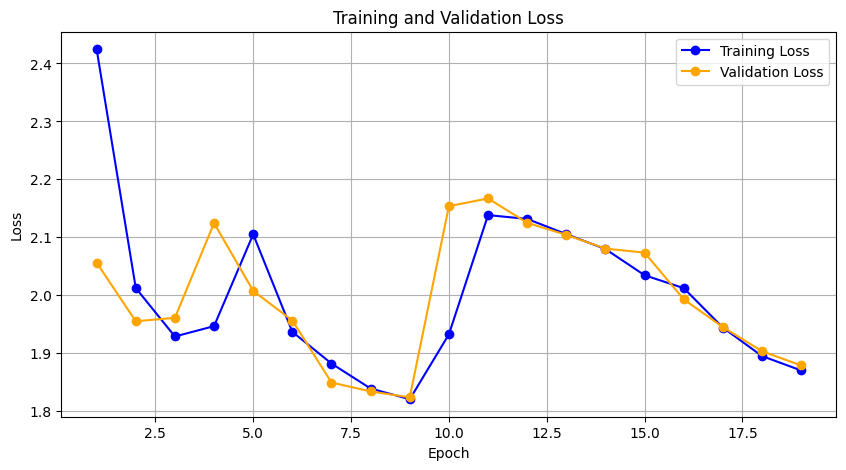

In [24]:
plot(train_loss_epoch_history, valid_loss_history)

Now adapt the helper plot function to plot the learning curves (validation error versus epoch) of the same model with 3 different learning rates 0.001, 0.0001, 0.00001 (you’ll also need to set higher max epoch num for a smaller learning rate).


=== Training with learning rate = 0.001 ===


Epoch [1/200]: 100%|██████████| 94/94 [00:00<00:00, 121.11it/s, loss=2.29]


Epoch [1/200]: Train loss: 2.2979, Valid loss: 2.2931 Valid acc: 0.1057


Epoch [2/200]: 100%|██████████| 94/94 [00:00<00:00, 98.46it/s, loss=2.28]


Epoch [2/200]: Train loss: 2.2862, Valid loss: 2.2806 Valid acc: 0.1346


...

Epoch [198/200]: Train loss: 2.2799, Valid loss: 2.2805 Valid acc: 0.1337


Epoch [199/200]: 100%|██████████| 94/94 [00:00<00:00, 116.66it/s, loss=2.28]


Epoch [199/200]: Train loss: 2.2798, Valid loss: 2.2804 Valid acc: 0.1346


Epoch [200/200]: 100%|██████████| 94/94 [00:00<00:00, 107.27it/s, loss=2.28]


Epoch [200/200]: Train loss: 2.2797, Valid loss: 2.2802 Valid acc: 0.1361


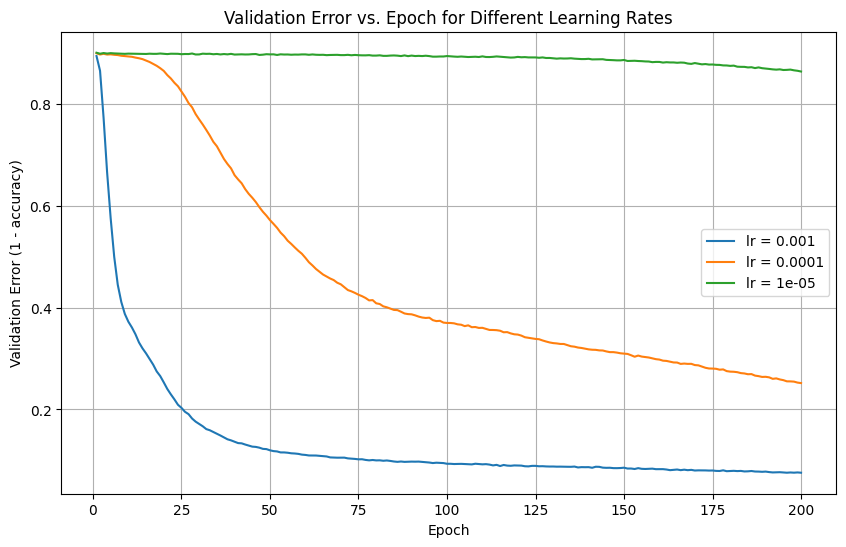

In [25]:
# TODO
# 3-(c)
learning_rates = [0.001, 0.0001, 0.00001]
n_epochs_3c = 200

valid_acc_histories = {}

for lr in learning_rates:
    print(f"\n=== Training with learning rate = {lr} ===")
    same_seed(environ_config['seed'])
    model_3c = My_2nd_MLP_Model(input_dim=784).to(environ_config['device'])
    config_3c = {
        'n_epochs': n_epochs_3c,
        'learning_rate': lr,
        'early_stop': n_epochs_3c + 1,
        'save_path': f'./models/model_3c_lr{lr}.ckpt',
    }
    _, _, valid_acc_history = trainer(
        train_loader, valid_loader, model_3c, config_3c, environ_config['device']
    )
    valid_acc_histories[lr] = valid_acc_history

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    val_error = 1 - np.array(valid_acc_histories[lr])
    plt.plot(range(1, len(val_error) + 1), val_error, label=f'lr = {lr}')

plt.xlabel('Epoch')
plt.ylabel('Validation Error (1 - accuracy)')
plt.title('Validation Error vs. Epoch for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

## Reference
This notebook uses code was orginally written by Heng-Jui Chang and modified by Cheng-Yen Yang.